# Customer Analytics & Churn Prediction

### Exploratory Data Analysis

This notebook explores customer demographics, service usage, billing patterns, and churn behavior to identify the key factors influencing customer retention.

In [1]:
# Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
# Dataset

df = pd.read_csv("../data/processed/telco_customer_churn_clean.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
total_customers = df.shape[0]

churned_customers = (df["Churn"] == "Yes").sum()

churn_rate = (churned_customers / total_customers) * 100

avg_monthly_charge = df["MonthlyCharges"].mean()

avg_tenure = df["tenure"].mean()

In [4]:
print(f"Total Customers      : {total_customers}")
print(f"Churned Customers    : {churned_customers}")
print(f"Churn Rate           : {churn_rate:.2f}%")
print(f"Average Tenure       : {avg_tenure:.2f} months")
print(f"Average Monthly Bill : ${avg_monthly_charge:.2f}")

Total Customers      : 7032
Churned Customers    : 1869
Churn Rate           : 26.58%
Average Tenure       : 32.42 months
Average Monthly Bill : $64.80


In [5]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

C:\Users\harsh\AppData\Local\Temp\ipykernel_24296\1551852905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Churn", palette="Set2")


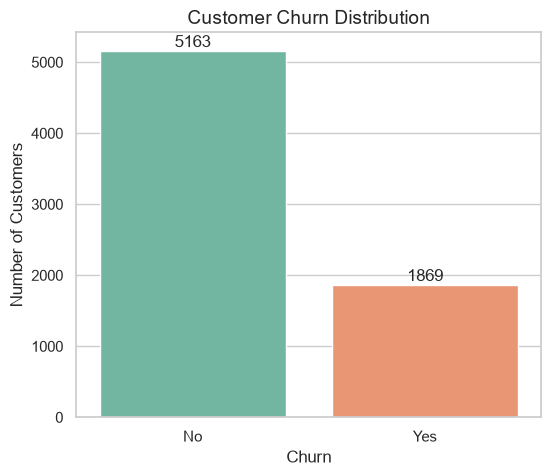

In [6]:
plt.figure(figsize=(6,5))

ax = sns.countplot(data=df, x="Churn", palette="Set2")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [7]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

### Observation

- Most customers have stayed with the company.
- Around one-fourth of the customers have churned.
- Since the classes are not perfectly balanced, we will keep this in mind while evaluating machine learning models.

In [9]:
# Gender Analysis
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


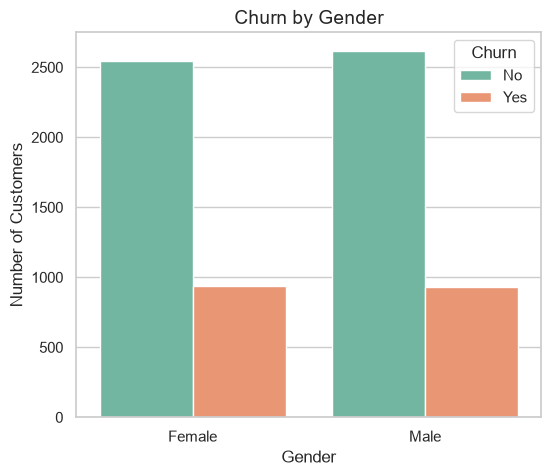

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn",
    palette="Set2"
)

plt.title("Churn by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [12]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

gender_churn.round(2)

Churn,No,Yes
gender,,
Female,73.04,26.96
Male,73.80,26.20


### Observation

- Male and female customers have a very similar churn pattern.
- Gender alone does not appear to be a strong indicator of customer churn.

In [13]:
# Contract Analysis
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [14]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


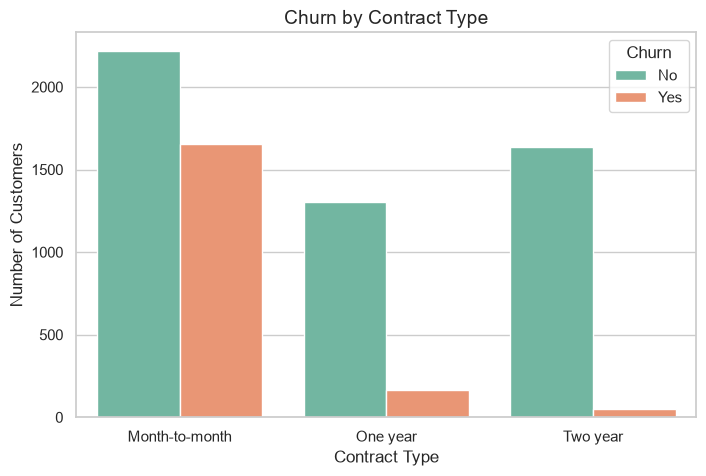

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set2"
)

plt.title("Churn by Contract Type", fontsize=14)
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- Customers with month-to-month contracts have the highest churn rate.
- Customers with one-year and two-year contracts are much more likely to stay.
- Long-term contracts appear to improve customer retention.

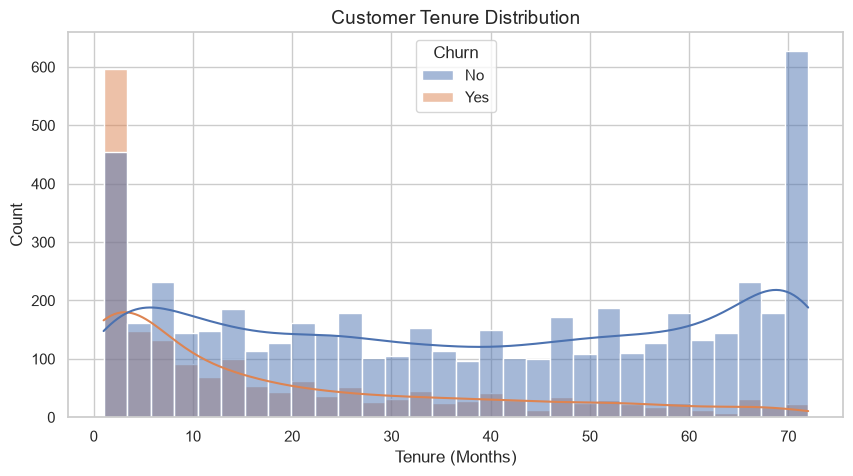

In [16]:
# Tenure Analysis
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution", fontsize=14)
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")

plt.show()

C:\Users\harsh\AppData\Local\Temp\ipykernel_24296\3214110166.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


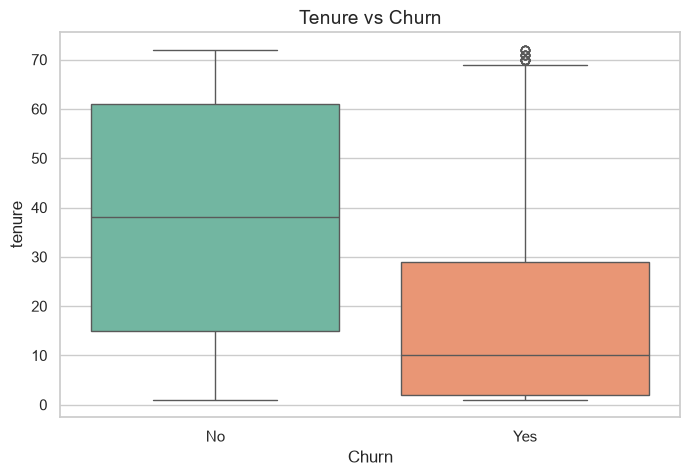

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    palette="Set2"
)

plt.title("Tenure vs Churn", fontsize=14)

plt.show()

### Observation

- Customers with shorter tenure are more likely to churn.
- Customers who remain with the company for many months tend to stay loyal.
- Customer retention efforts should focus on new customers during their early months.

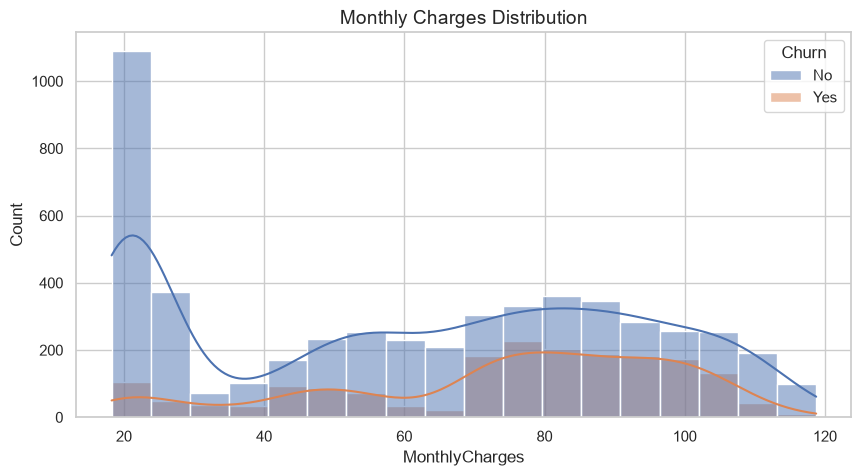

In [18]:
# Monthly Charges
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    kde=True
)

plt.title("Monthly Charges Distribution", fontsize=14)

plt.show()

C:\Users\harsh\AppData\Local\Temp\ipykernel_24296\1691569149.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


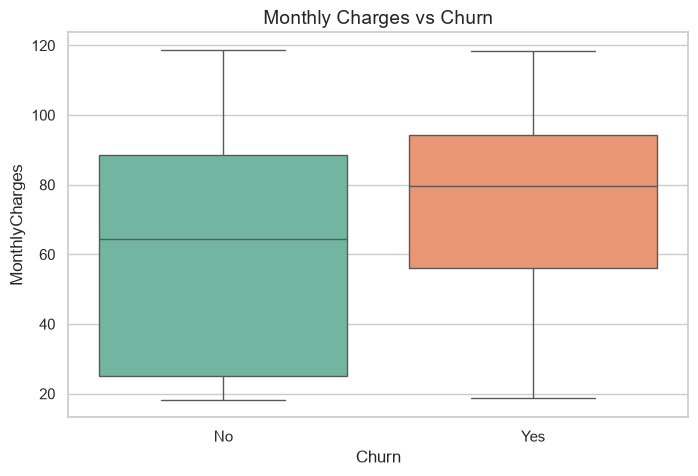

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    palette="Set2"
)

plt.title("Monthly Charges vs Churn", fontsize=14)

plt.show()

### Observation

- Customers paying higher monthly charges tend to churn more frequently.
- Price-sensitive customers may be more likely to switch to competitors.
- Pricing strategy and bundled services may help reduce churn.

In [20]:
# Contract Type
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [21]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


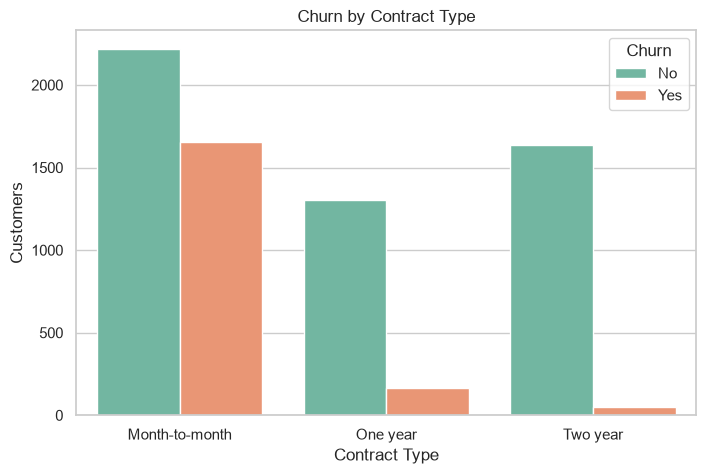

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set2"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customers")

plt.show()

### Observation

- Month-to-month customers have the highest churn rate.
- Customers on one-year and two-year contracts are significantly more likely to stay.
- Longer contracts appear to improve customer retention.

In [23]:
# Internet service
pd.crosstab(df["InternetService"], df["Churn"])


Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [24]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


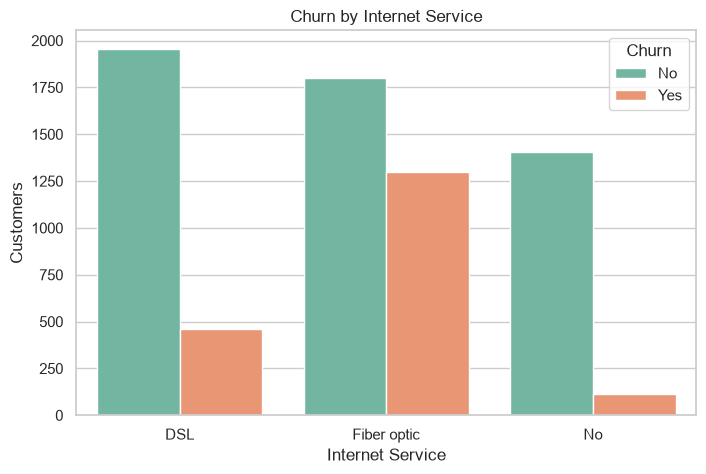

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    palette="Set2"
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Customers")

plt.show()

### Observation

- Fiber optic customers show a higher churn rate compared to DSL users.
- Customers without internet service rarely churn.
- Service quality or pricing may influence churn among fiber customers.

In [26]:
# Payment method
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


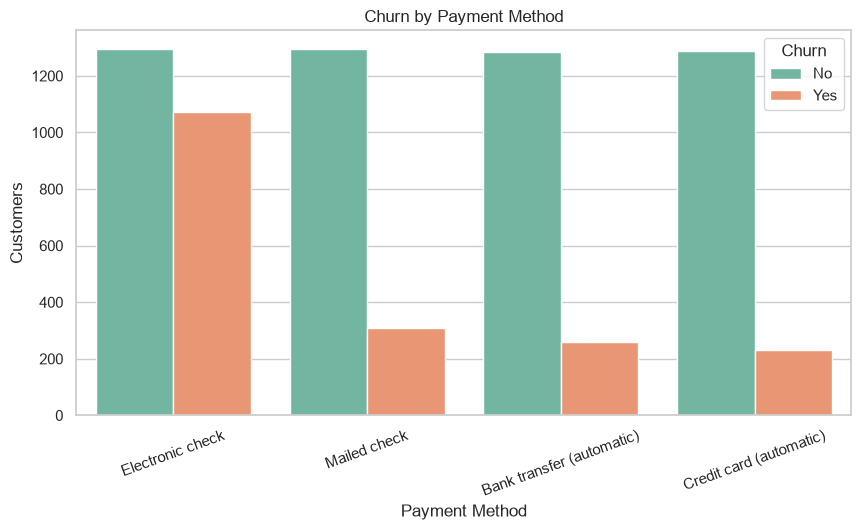

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn",
    palette="Set2"
)

plt.xticks(rotation=20)

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customers")

plt.show()

### Observation

- Customers using electronic check have the highest churn rate.
- Automatic payment methods are associated with better customer retention.

In [28]:
# Tech support 
tech_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

tech_churn.round(2)

Churn,No,Yes
TechSupport,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20


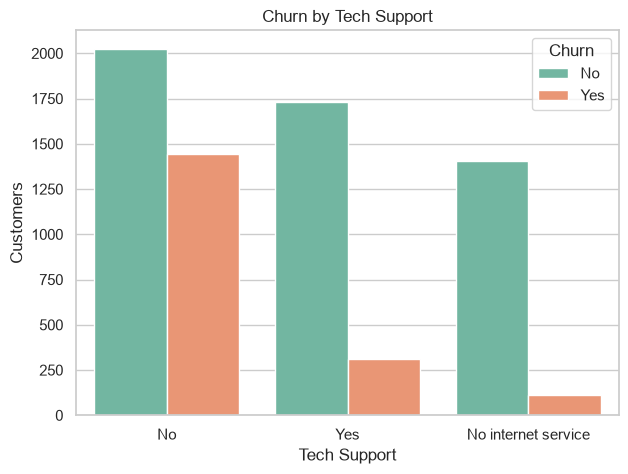

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn",
    palette="Set2"
)

plt.title("Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Customers")

plt.show()

### Observation

- Customers without technical support are more likely to churn.
- Providing technical support may improve customer satisfaction and retention.

In [30]:
# Online Security
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

security_churn.round(2)

Churn,No,Yes
OnlineSecurity,,
No,58.22,41.78
No internet service,92.57,7.43
Yes,85.36,14.64


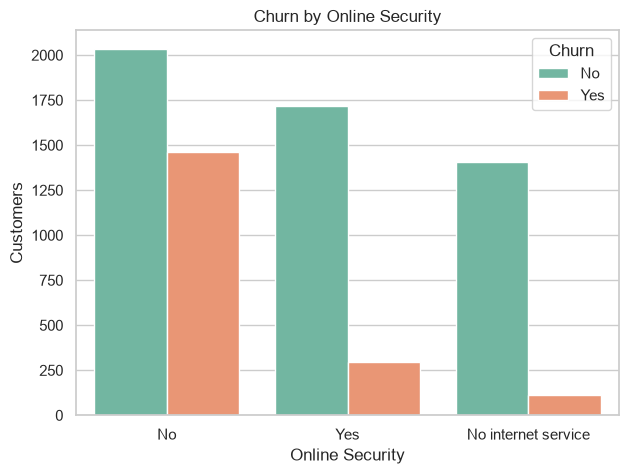

In [31]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn",
    palette="Set2"
)

plt.title("Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Customers")

plt.show()

### Observation

- Customers without online security tend to churn more frequently.
- Value-added services may contribute to improved customer loyalty.

In [32]:
# Correlation Heatmap
from sklearn.preprocessing import LabelEncoder

corr_df = df.drop(columns="customerID").copy()

for col in corr_df.select_dtypes(include="object").columns:
    corr_df[col] = LabelEncoder().fit_transform(corr_df[col])

C:\Users\harsh\AppData\Local\Temp\ipykernel_24296\1093803759.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in corr_df.select_dtypes(include="object").columns:


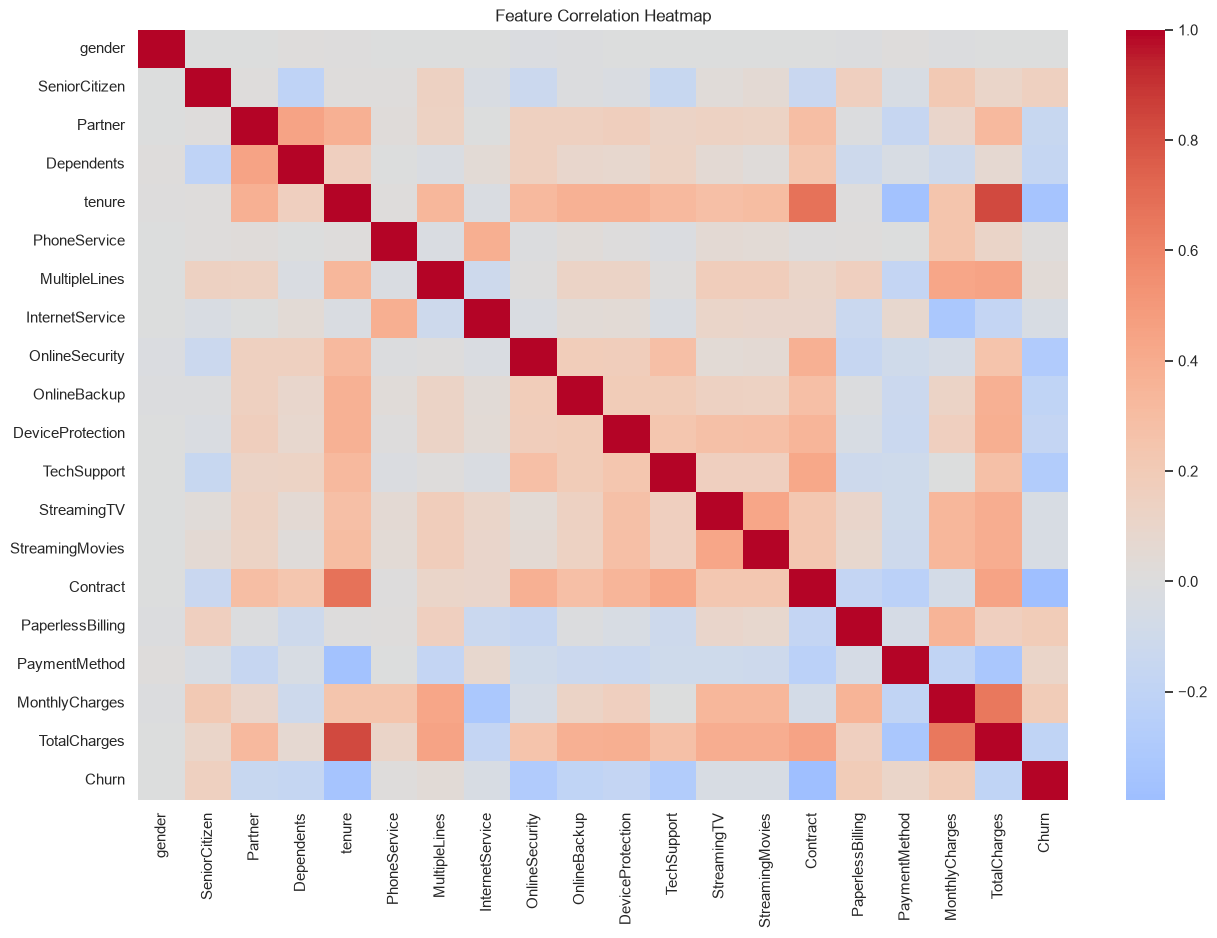

In [36]:
plt.figure(figsize=(15,10))

sns.heatmap(
    corr_df.corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Feature Correlation Heatmap")

plt.show()

# Key Business Insights

- Customers with month-to-month contracts are significantly more likely to churn.
- Higher monthly charges are associated with increased churn.
- Customers with shorter tenure exhibit a higher churn rate.
- Fiber optic users show a relatively higher churn rate.
- Customers without technical support or online security churn more frequently.
- Electronic check is associated with the highest churn among payment methods.